### 1. (25 points)

<IPython.core.display.Javascript object>


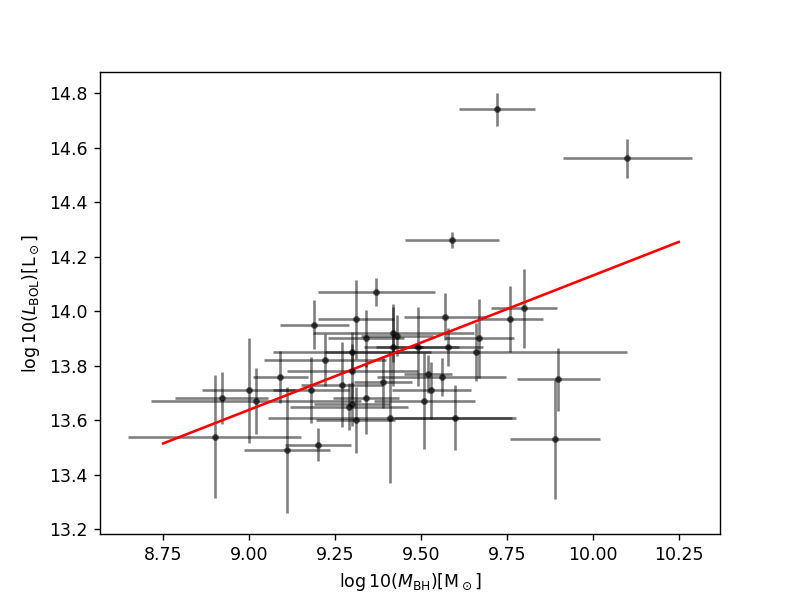

<ErrorbarContainer object of 3 artists>

In [2]:
# Part A
#

d = np.loadtxt("LbolMbh2.dat",unpack=True)
lL = d[0]
lM = d[1]
slL = d[2]
slM = d[3]

fig, ax = plt.subplots()

ax.set_xlabel(r"$\log10(M_{\rm BH}) [{\rm M_\odot}]$")
ax.set_ylabel(r"$\log10(L_{\rm BOL}) [{\rm L_\odot}]$")

ax.errorbar(lM,lL,slL,slM,"k.",alpha=0.5)

In [3]:
# Part B
#

from timeit import default_timer as timer # time all methods

#
# Choose a pivot point (to be played with in class)
#
lMcen = np.mean(lM)

do_marg = False # do marginlizaion or the initial maximum?

#
# Function we integrate
#
def ifun(lL,lM,t,lLi,lMi,slLi,slMi):
    '''
    Return p(lL,lM) function for the given model parametes times Gaussian for one data point
    Inputs: integration variables lL=log10(L), lM=log10(M)
            vector of parameters t
            data point: log10(L_i), log10(M_i), and their errors.
    '''
    if(do_marg):
        sint = sint_marg
    else:
        sint = t[2]
    #

    lL0 = t[0]*(lM-lMcen) + t[1]
    v = np.exp(-0.5*(((lL-lLi)/slLi)**2+((lM-lMi)/slMi)**2+((lL-lL0)/sint)**2))
    #print(lM,lL,v)
    return v
#


#
# Minus-log-likelihood
#
def mllfun(t):
    '''
    Return -log(L) where L is the likelihood
    Inputs: vector of parameters t
    '''
    if(do_marg):
        sint = sint_marg
    else:
        sint = t[2]
    #

    fact = 1/(2*np.pi)**1.5/sint
    
    start_time = timer()
    ret = 0
    for i in range(len(lL)):
        lM1 = lM[i] - 5*slM[i]
        lM2 = lM[i] + 5*slM[i]
        lL1 = lL[i] - 5*slL[i]
        lL2 = lL[i] + 5*slL[i]
        v = scipy.integrate.dblquad(ifun,lM1,lM2,lL1,lL2,args=(t,lL[i],lM[i],slL[i],slM[i]))/(slL[i]*slM[i])
        #print(lL[i],lM[i],slL[i],slM[i],fact*v[0])
        if(v[0] > 0): ret -= np.log(fact*v[0])  # we return -log(L), hence -=
    #
    
    if(not do_marg): print(t," mll=%g time=%g"%(ret,timer()-start_time))
    
    return ret
#

t0 = [ 1, 13.4, 1 ]
print(mllfun(t0))

[1, 13.4, 1]  mll=44.4253 time=6.27588
44.42533354155744


In [4]:
# Part C
#

bounds0 = scipy.optimize.Bounds()
bounds0.lb = np.array([-1,10,0.1])
bounds0.ub = np.array([ 2,20,3])

start_time = timer()
res = scipy.optimize.minimize(mllfun,t0,bounds=bounds0)
print("optimization time=%g"%(timer()-start_time))

[ 1.  13.4  1. ]  mll=44.4253 time=0.26117
[ 1.00000001 13.4         1.        ]  mll=44.4253 time=0.255359
[ 1.         13.40000001  1.        ]  mll=44.4253 time=0.258956
[ 1.         13.4         1.00000001]  mll=44.4253 time=0.258282
[-1.  20.   0.1]  mll=1791.32 time=0.0451407
[-0.99999999 20.          0.1       ]  mll=1791.32 time=0.044872
[-1.         19.99999999  0.1       ]  mll=1791.32 time=0.0448718
[-1.         20.          0.10000001]  mll=1791.32 time=0.044981
[ 0.33486375 15.59494962  0.70068869]  mll=155.259 time=0.220614
[ 0.33486376 15.59494962  0.70068869]  mll=155.259 time=0.218525
[ 0.33486375 15.59494963  0.70068869]  mll=155.259 time=0.218133
[ 0.33486375 15.59494962  0.7006887 ]  mll=155.259 time=0.218859
[ 0.8496646  13.89610681  0.93234907]  mll=37.897 time=0.264911
[ 0.84966461 13.89610681  0.93234907]  mll=37.897 time=0.264677
[ 0.8496646  13.89610682  0.93234907]  mll=37.897 time=0.257831
[ 0.8496646  13.89610681  0.93234908]  mll=37.897 time=0.259462
[ 0.6

In [5]:
print(res.x,res.fun)

lMp = np.array([8.75,10.25])
ax.plot(lMp,res.x[0]*(lMp-lMcen)+res.x[1],"r-")

[ 0.49248684 13.84313121  0.1863116 ] -3.5122146180730436


0 0.046577899604872776 13.326051192105142 0.00026174413620172476
1 0.06055126948633462 11.463204989460756 0.0007098776541965002
2 0.07452463936779645 9.41106270884931 0.0021568018764666075
3 0.08849800924925827 7.331434133190872 0.006775896833851713
4 0.10247137913072012 5.375329851844035 0.020423478834169617
5 0.11644474901218194 3.662723201416626 0.05564261782546309
6 0.13041811889364377 2.2686301306011267 0.1320165473531385
7 0.1443914887751056 1.222113596223771 0.2689462564155134
8 0.15836485865656744 0.5162889258926713 0.4724290280584117
9 0.17233822853802927 0.12206700420294236 0.7268033803148137
10 0.1863115984194911 0.0 1.0
11 0.20028496830095294 0.10829522633634836 0.7420934064099399
12 0.21425833818241474 0.40735010880855294 0.5233175588920229
13 0.22823170806387663 0.8618600706130208 0.35321868708020043
14 0.24220507794533844 1.4414711778667075 0.2299014202053925
15 0.25617844782680027 2.1206607438247103 0.14532383691879525
16 0.2701518177082621 2.878264584587644 0.089782735

<IPython.core.display.Javascript object>


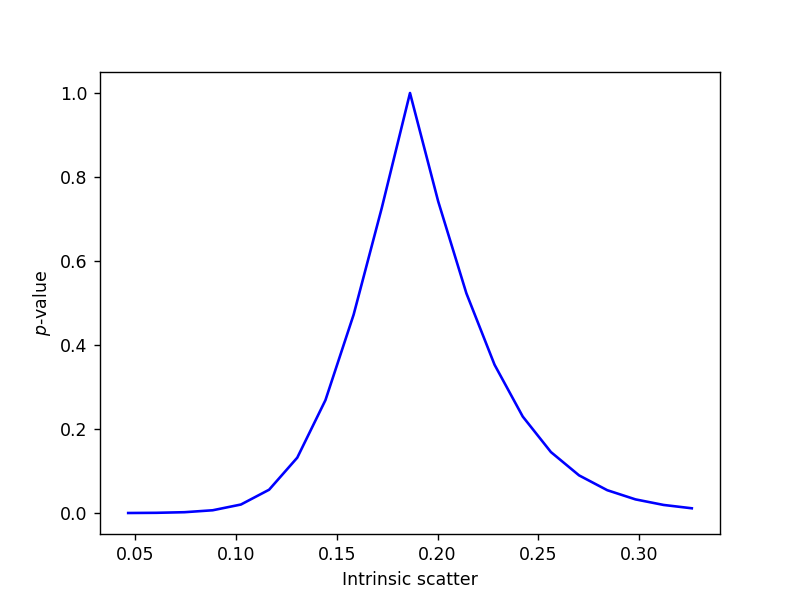

In [6]:
do_marg = True

n = 20
svals = np.zeros((n+1,))
lvals = np.zeros((n+1,))

for i in range(n+1):
    sint_marg = res.x[2]*(1+1.5/n*(i-n/2))
    svals[i] = sint_marg
    t = [res.x[0],res.x[1]]
    r = scipy.optimize.minimize(mllfun,t)
    chisq = r.fun - res.fun
    lvals[i] = 1 - scipy.stats.chi2.cdf(chisq,1)
    print(i,sint_marg,chisq,lvals[i])
#

fig, ax = plt.subplots()

ax.set_xlabel(r"Intrinsic scatter")
ax.set_ylabel(r"$p$-value")

ax.plot(svals,lvals,"b-")

### 2. (25 points)

<IPython.core.display.Javascript object>


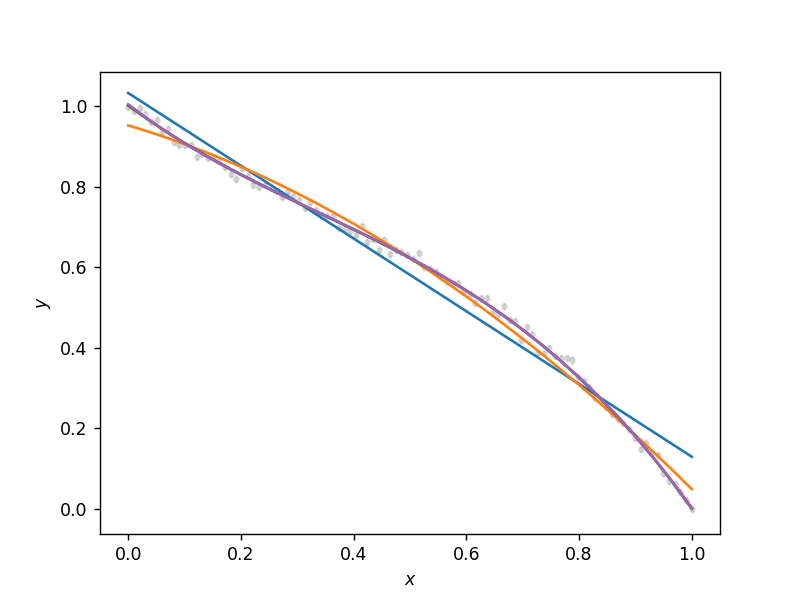

<ErrorbarContainer object of 3 artists>

In [18]:
m = 100

x = np.linspace(0,1,m)

y = 1 - x + x**2 - x**3
sy = 0.01
y += sy*np.random.standard_normal(m)

fig, ax = plt.subplots()

ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")

ax.errorbar(x,y,sy,fmt=".",color="gray",alpha=0.2,zorder=-1)

In [19]:
# Part B
#

def lfun(t,n):
    '''
    Cost function for y(x) with n+1 parameters (n-degree polynomial fit)
    '''
    yf = np.zeros_like(x)
    for i in range(n+1):
        yf += t[i]*x**i
    #
    return (y-yf)/sy
#


ns = [ 1, 2, 3, 4, 5 ]
tres = [0]*len(ns)
chisq = [0]*len(ns)

for i in range(len(ns)):
    t0 = np.zeros((ns[i]+1,))
    tres[i] = scipy.optimize.least_squares(lfun,t0,args=(ns[i],)).x
    chisq[i] = np.sum(lfun(tres[i],ns[i])**2)
    print(ns[i],tres[i],chisq[i],1-scipy.stats.chi2.cdf(chisq[i],len(x)-ns[i]-1))
    xp = np.linspace(np.amin(x),np.amax(x),31)
    yp = np.zeros_like(xp)
    for n in range(len(tres[i])):
        yp += tres[i][n]*xp**n
    #
    ax.plot(xp,yp)
#



1 [ 1.0319126  -0.90219029] 1873.9876338732518 0.0
2 [ 0.95159895 -0.41539125 -0.48679904] 504.1504171752698 0.0
3 [ 1.0003211  -1.01517699  1.02022529 -1.00468289] 121.78325568785375 0.03892082240719119
4 [ 1.00239383 -1.05859706  1.21791367 -1.31321951  0.15426832] 121.2001736280484 0.03616503657786141
5 [ 1.00395646 -1.10901502  1.57795101 -2.28044174  1.24506425 -0.43631834] 120.90048533984121 0.032266752897371465


<IPython.core.display.Javascript object>


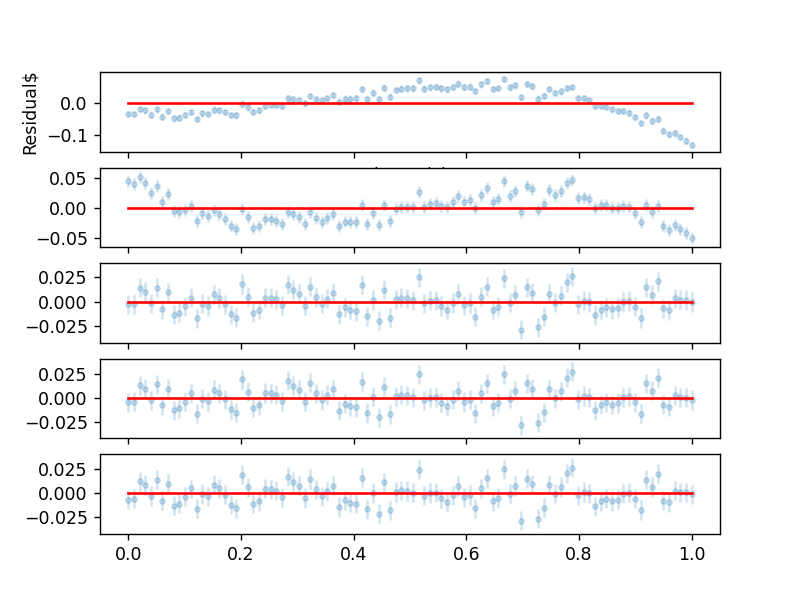

-2.6922908347160045e-17 0.04328957881376593
-1.033895191682177e-17 0.02245329412748316
-5.377588565419478e-17 0.011035545101527782
-4.937598455101444e-12 0.011009095041285109
-5.803066360776654e-15 0.01099547567592422


In [20]:
fig, axx = plt.subplots(nrows=len(ns),sharex=True)

axx[0].set_xlabel(r"$\log10(z)$")
axx[0].set_ylabel(r"Residual$")

for i in range(len(tres)):
    t = tres[i]
    r = np.zeros_like(x)
    for n in range(len(t)):
        r += t[n]*x**n
    #
    r = y - r
    print(np.mean(r),np.std(r))
    
    ax = axx[i]
    ax.errorbar(x,r,sy,fmt=".",alpha=0.2,zorder=-1)
    ax.plot([np.amin(x),np.amax(x)],[0,0],"r-")
#



In [21]:
for i in range(len(tres)):
    ndf = len(x) - ns[i]
    print("n=%d  chisq/dof=%5.3f AIC=%g BIC=%g"%(ns[i],chisq[i]/ndf,2*ns[i]+chisq[i],ns[i]*np.log(len(x))+chisq[i]))
#


n=1  chisq/dof=18.929 AIC=1875.99 BIC=1878.59
n=2  chisq/dof=5.144 AIC=508.15 BIC=513.361
n=3  chisq/dof=1.255 AIC=127.783 BIC=135.599
n=4  chisq/dof=1.263 AIC=129.2 BIC=139.621
n=5  chisq/dof=1.273 AIC=130.9 BIC=143.926
